**Author:** Qingyu (Wendy) Mao  
**Affiliation:** University of Washington, Seattle  
**Email:** [qingym6@uw.edu](mailto:qingym6@uw.edu)  
**GitHub:** [github.com/qingym6](https://github.com/qingym6)  
**LinkedIn:** [linkedin.com/in/qingyu-mao](https://www.linkedin.com/in/qingyu-mao)

---

# Recommending Personalized Diet Categories and Foods Based on Nutrient Needs

This project aims to explore how data-driven methods can provide personalized diet recommendations that match individuals’ demographic and lifestyle characteristics with foods that help them meet nutrient targets.

## Summary of Questions and Results
1. **Are there statistically significant differences in demographic and lifestyle features among different diet recommendation groups?**  
- Is there a statistically significant difference in BMI among individuals recommended Balanced, Low_Carb, and Low_Sodium diets?

The one-way ANOVA test showed no statistically significant difference in BMI among individuals recommended Balanced, Low_Carb, and Low_Sodium diets (p = 0.164 > 0.05).

- Are older individuals more likely to be recommended low-sodium diets?

There is no statistically significant difference in mean age between individuals recommended a Low_Sodium diet and those given other diet recommendations. Older individuals are not more likely to be recommended low-sodium diets.

- Is the physical activity level associated with the diet recommendation categories?

Not really, individuals with different physical activity levels appear to receive similar diet recommendations, suggesting that physical activity level does not meaningfully influence the type of diet assigned.

2. **Can we predict the best diet recommendation for an individual based on demographic and lifestyle features (e.g., age, physical activity, BMI, diet type)?**  

Yes. I predict a diet recommendation for an individual by using three different machine learning models: kNN, SVM, and the decision tree. More detailed research results are presented in the Results section.

3. **What are the top foods that can be recommended to help individuals meet their nutrient targets in each category of nutrients?**

What I did for this question is that I filtered the nutrient composition dataset based on individuals' allergen (simple assumption) and diet recommendation type, and ranked the dataframe in an ascending order, so that we can recognize the foods that are low-carb or low-sodium. More detailed research results and explanations are presented in the Results section.

5. **Which machine-learning algorithm performs best for personalized diet recommendations?**  

Surprisingly, SVM and the decision tree both perform perfectly for personalized diet recommendations. More detailed comparison, assumption, and limitations are presented in the Results section.

---

## Motivation

My motivation for this project comes from my current nutrition class, where I have learned how essential food nutrients are to our daily life and long-term health. Nutrients affect everything from energy levels to disease prevention, and understanding their roles has made me more aware of how diet choices directly impact well-being. In today’s society, more and more people are paying attention to their health, looking for ways to personalize their diets based on their unique characteristics and needs.

I want to explore how data-driven methods can provide personalized diet recommendations by taking into account individual information such as gender, age, BMI, disease history, and lifestyle factors. Rather than offering only general diet category suggestions, my goal is to go one step further by recommending specific foods that help individuals meet their nutrient targets. This way, people can make informed decisions about what kinds of foods they should eat more of or avoid, enabling them to follow personalized nutrition strategies that are practical, actionable, and beneficial for their health.

---


## Data Setting
**Datasets:**
- **[Diet Recommendation Dataset](https://www.kaggle.com/datasets/ziya07/diet-recommendations-dataset/data)**
    - This dataset simulates information that can be used to build an intelligent system for personalized diet recommendations. It brings together detailed demographic information, medical history, dietary preferences, and key health indicators, making it ideal for applying machine learning techniques in the fields of nutrition and healthcare. There are 1000 rows of patients and 20 columns of features in total. I will use this dataset primarily to train and evaluate models that predict appropriate diet categories based on personal characteristics.(Kaggle: patient-level demographics, lifestyle, indicators, and a recommended diet label).
- **[Nutrient Composition Dataset](https://www.kaggle.com/datasets/thedevastator/now-with-more-nutrients/data)**
    - This dataset provides detailed nutrient information for more than 9000 foods, including their macronutrient breakdown and food group classifications. There are 9318 rows and 29 columns of nutrient contents. It forms the basis for generating precise food recommendations tailored to an individual’s nutrient needs once an appropriate diet recommendation has been predicted.

## Diet Recommendation Dataset Description

**Rows (Observations):** 1,000  
**Columns (Features):** 20  
**Target Column:** `Diet_Recommendation`

### Key Features

| **Feature Name** | **Description** |
|-------------------|-----------------|
| `Patient_ID` | Unique identifier for each patient. |
| `Age` | Age of the patient. |
| `Gender` | Gender of the patient (*Male*, *Female*). |
| `Weight_kg` | Weight of the patient in kilograms. |
| `Height_cm` | Height of the patient in centimeters. |
| `BMI` | Body Mass Index, calculated as Weight (kg) / (Height (m)²). |
| `Disease_Type` | Primary disease diagnosed (*Diabetes*, *Hypertension*, *Obesity*, or *None*). |
| `Severity` | Severity of the disease (*Mild*, *Moderate*, *Severe*). |
| `Physical_Activity_Level` | Level of physical activity (*Sedentary*, *Moderate*, *Active*). |
| `Daily_Caloric_Intake` | Average daily calorie consumption. |
| `Cholesterol_mg/dL` | Cholesterol level in mg/dL. |
| `Blood_Pressure_mmHg` | Average blood pressure in mmHg. |
| `Glucose_mg/dL` | Blood glucose level in mg/dL. |
| `Dietary_Restrictions` | Known dietary restrictions (*Low_Sodium*, *Low_Sugar*, *None*). |
| `Allergies` | Known food allergies (*Peanuts*, *Gluten*, *None*). |
| `Preferred_Cuisine` | Patient’s preferred cuisine (*Indian*, *Italian*, *Chinese*, *Mexican*). |
| `Weekly_Exercise_Hours` | Number of hours exercised per week. |
| `Adherence_to_Diet_Plan` | Patient’s adherence to a suggested diet plan (percentage). |
| `Dietary_Nutrient_Imbalance_Score` | A score indicating nutrient imbalance in the patient’s diet. |


### Target Column

**`Diet_Recommendation`** — Suggested dietary plan based on individual health conditions:

- **Low_Carb:** For managing diabetes or weight-related concerns.  
- **Low_Sodium:** For hypertension or cardiovascular health.  
- **Balanced:** For general health improvement or non-specific requirements.

## Nutrient Composition Dataset Description

**Rows (Observations):** 9318  
**Columns (Features):** 29  

### Key Features

| **Feature Name**   | **Description**                                                                        |
| ------------------ | -------------------------------------------------------------------------------------- |
| `NDB_No`           | Unique identifier from the National Nutrient Database for each food item.              |
| `Descrip`          | Description or name of the food item.                                                  |
| `Energy_kcal`      | Energy provided by the food in kilocalories per 100g.                                  |
| `Protein_g`        | Amount of protein in grams per 100g of the food.                                       |
| `Fat_g`            | Total fat content in grams per 100g.                                                   |
| `Saturated_fats_g` | Amount of saturated fat in grams per 100g.                                             |
| `Carb_g`           | Total carbohydrates in grams per 100g.                                                 |
| `Fiber_g`          | Amount of dietary fiber in grams per 100g.                                             |
| `Sugar_g`          | Amount of sugar in grams per 100g.                                                     |
| `Calcium_mg`       | Calcium content in milligrams per 100g.                                                |
| `Iron_mg`          | Iron content in milligrams per 100g.                                                   |
| `Magnesium_mg`     | Magnesium content in milligrams per 100g.                                              |
| `Phosphorus_mg`    | Phosphorus content in milligrams per 100g.                                             |
| `Potassium_mg`     | Potassium content in milligrams per 100g.                                              |
| `Sodium_mg`        | Sodium content in milligrams per 100g.                                                 |
| `Zinc_mg`          | Zinc content in milligrams per 100g.                                                   |
| `Copper_mcg`       | Copper content in micrograms per 100g.                                                 |
| `Manganese_mg`     | Manganese content in milligrams per 100g.                                              |
| `Selenium_mcg`     | Selenium content in micrograms per 100g.                                               |
| `VitC_mg`          | Vitamin C content in milligrams per 100g.                                              |
| `Thiamin_mg`       | Thiamin content in milligrams per 100g.                                                |
| `Riboflavin_mg`    | Riboflavin content in milligrams per 100g.                                             |
| `Niacin_mg`        | Niacin content in milligrams per 100g.                                                 |
| `VitB6_mg`         | Vitamin B6 content in milligrams per 100g.                                             |
| `Folate`           | Folate content in micrograms per 100g.                                                 |
| `VitB12_mcg`       | Vitamin B12 content in micrograms per 100g.                                            |
| `VitA_mcg`         | Vitamin A content in micrograms per 100g.                                              |
| `VitE_mg`          | Vitamin E content in milligrams per 100g.                                              |
| `VitD2_mcg`        | Vitamin D2 content in micrograms per 100g.                                             |

---

## Method

This project was completed in four main stages: **Dataset Preprocessing**, **Exploratory Data Analysis (EDA) and Statistical Hypothesis Testing**, **Advanced Machine Learning**, and **Prediction**.  


### **Task 1: Dataset Preprocessing**

The first step involved loading, cleaning, and preparing two datasets — a **diet recommendation dataset** containing patient demographics, lifestyle factors, and recommended diet categories, and a **nutrient composition dataset** containing detailed nutrient values for various foods.
- Data loading and Handling missing values
- Exploratory Data Analysis (EDA)   
Conducted initial EDA to understand data distribution, detect outliers, and identify patterns among variables. Generated summary statistics (`describe()`), frequency tables, and visualizations including:
  - Histograms and boxplots for numeric variables (e.g., BMI, Age, Calories).
  - Count plots for categorical features such as `Diet_Recommendation` and `Physical_Activity_Level`.
  - Scatter plots (e.g., BMI vs Age, Sodium vs Energy) to explore potential correlations.
  
  The EDA revealed that BMI, age, and activity level vary across diet categories, motivating the specific statistical tests used later.

---

### **Task 2: Statistical Hypothesis Testing**

To evaluate the relationships observed during EDA, three statistical tests were applied to address the **challenge goal of Statistical Hypothesis Testing**.

1. **ANOVA (BMI vs Diet Category)**  
   - **Purpose:** Determine whether mean BMI differs among individuals with different diet recommendations.  
   - **Verification:** Checked normality within groups (Shapiro–Wilk) and equality of variances (Levene’s test).  
   - **Outputs:** ANOVA table with F-statistic and p-value to evaluate group differences.

2. ***t*-Test (Age: Low Sodium vs Others)**  
   - **Purpose:** Compare mean ages between individuals recommended a Low_Sodium diet and those with other diets.  
   - **Verification:** Tested normality for both groups and equal variances; used Welch’s *t*-test if variances differed.  
   - **Outputs:** t-statistic, p-value, and interpretation of group mean differences.

3. **Chi-Square Test (Physical Activity vs Diet)**  
   - **Purpose:** Examine whether physical activity level is associated with diet category.  
   - **Verification:** Ensured all expected frequencies ≥ 5 and visualized observed proportions.  
   - **Outputs:** Chi-square statistic, degrees of freedom, and p-value, with Cramér’s V for association strength.

---

### **Task 3: Advanced Machine Learning**

After statistical testing, I applied machine learning methods to predict an individual’s recommended diet category based on demographic and lifestyle features. Three models were built and compared using scikit-learn:

- **k-Nearest Neighbors (kNN):**  
  Tuned *k* using cross-validation to balance bias and variance.

- **Decision Tree Classifier:**  
  Tested various tree depths and splitting criteria; evaluated interpretability and overfitting risks.

- **Support Vector Machine (SVM):**  
  Compared linear and RBF kernels; optimized hyperparameters (C and gamma) for best classification accuracy.

**Model Evaluation:**  
All models were evaluated using **accuracy**, **precision**, **recall**, **F1-score**, and **ROC-AUC** metrics.  
The model with the best generalization performance on the validation set was selected for final predictions.

---

### **Task 4: Prediction and Food Recommendation**

In the final step, I used the best-performing model to predict diet recommendations for individuals based on their health and lifestyle profiles.  
Then, I linked predictions to the nutrient composition dataset to generate personalized food recommendations.

**Functions developed:**
- Ranks foods based on how well their nutrient profiles align with a specific diet type (e.g., low sodium or low carb).  
- Returns the top-ranked food options per diet category.

**Outputs:**
- A ranked table of food recommendations per diet type.  


---

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import chi2_contingency

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report, RocCurveDisplay, roc_curve, auc
)

# Utilities
import warnings
warnings.filterwarnings("ignore")

from pprint import pprint
import doctest
import os

---
## EDA Results

**Summary of Findings**

The exploratory data analysis revealed that the Diet Recommendation dataset contains a mix of demographic, health, lifestyle, and dietary-restriction variables, and that most missing values occur only in optional categorical fields related to medical or dietary information. Quantitative variables such as Age, BMI, cholesterol, blood pressure, and glucose fall within realistic human ranges and show no extreme outliers. Visualizations showed that neither age nor BMI varies meaningfully across diet recommendation categories—suggesting that diet assignments are not driven by simple demographic factors. The Nutrient Composition dataset was found to be fully clean without missing values.

**What steps did you take during your EDA that prepared the work you conducted for the rest of your analysis?**

1. Missing Data Analysis

- Wrote a custom missing_summary() function to compute total missing values, percent missing, and missing columns.

- Found 4.30% missingness, all in categorical medical/dietary variables (Disease_Type, Dietary_Restrictions, Allergies).

- Decided to impute missing values using "None" or "Unknown" since these fields represent optional self-reported information.

2. Variable Identification

- Listed and described all key variables of interest related to my research questions in both datasets (e.g., Age, BMI, Disease Type, Preferred Cuisine, Carb_g, Sodium_mg).

- Linked each variable to its planned role in the analysis (t-test, ANOVA, chi-square, or modeling).

3. Summary Statistics

- Computed seven-number summaries for quantitative variables using describe().

- Generated value counts for all categorical variables.

- Verified that variables have reasonable ranges, balanced category distributions, no extreme anomalies, and we can use t-test, ANOVA, and chi-square to do the hypothesis test.

4. Visualization of Key Variables

- Created a bar chart showing average BMI across diet categories, which revealed very similar BMI across Balanced, Low_Carb, and Low_Sodium groups.

- Created a boxplot of age distribution across diet categories, again showing overlapping distributions.

- These findings suggested that demographic features alone are not strong predictors of diet category.

**What did you learn about your data from doing the EDA?**

I learned that missing data is structured, appearing only in optional categorical variables and not affecting numeric computations, meaning the dataset of diet recommendations is highly cleaned before. Diet categories are relatively balanced, which is beneficial for classification models. Quantitative health indicators (BMI, cholesterol, glucose, blood pressure) are well distributed and suitable for parametric tests. The diet recommendations likely depend on medical conditions or dietary restrictions instead of age or BMI. The nutrient dataset is also clean, standardized, and suitable for later food-matching tasks.

**How did your understanding of the data setting change?**

Before doing EDA, I expected variables like age or BMI to show big differences across diet categories. After examining the distributions and visualizations, I learned that there is no statistically significant difference across diet recommendations, especially for age, BMI, and physical activity level (three features I examined for research question 1. I realized that categorical self-reported features such as disease type and dietary restrictions may play a more central role in explaining diet assignments. Also, the dataset represents a realistic decision-making scenario where multiple factors interact, and no single variable explains the target outcome. Therefore, modeling will need to incorporate multiple predictors rather than relying on simple one-variable relationships.

In addition, I find some limitations in the nutrient composition dataset. The biggest problem is that I cannot tell what the ingredients of a food are. What I know is the nutrients that a food contains. Therefore, I can hardly tell whether a food can cause an allergy or not, such as gluten and peanuts. This is a huge limitation in my later food recommendations. But this is also a good chance for me to cultivate the sense of how to select datasets for the future.

In [2]:
diet_rec = pd.read_csv("diet_recommendations_dataset.csv")

In [3]:
nutrient = pd.read_csv("cleaned_ingredients.csv")

---
## Challenge Goals

My project will meet the following two challenge goals: **Statistical Hypothesis Testing** and **Advanced Machine Learning**.

Notes: I changed the nutrient composition dataset to a bigger one that contains sodium content. Here is the [link](https://www.kaggle.com/datasets/thedevastator/now-with-more-nutrients/data) to the new dataset. 
In my previous nutrient dataset, there was no sodium content, so I decided to change it. But my challenge goals still stay the same.

### Statistical Hypothesis Testing

#### **1. ANOVA**
**Question:** Is there a statistically significant difference in BMI among individuals recommended *Balanced*, *Low_Carb*, and *Low_Sodium* diets?  

**Null hypothesis (H₀):**  
μ<sub>Balanced</sub> = μ<sub>Low Carb</sub> = μ<sub>Low Sodium</sub>  

**Alternative hypothesis (H₁):**  
At least one group mean differs.

---

#### **2. *t*-Test**
**Question:** Are older individuals more likely to be recommended low-sodium diets?  

**Null hypothesis (H₀):**  
μ<sub>Low Sodium</sub> = μ<sub>Others</sub>  

**Alternative hypothesis (H₁):**  
μ<sub>Low Sodium</sub> ≠ μ<sub>Others</sub>

---

#### **3. Chi-Square Test**
**Question:** Is the physical activity level associated with the diet recommendation categories?  

**Null hypothesis (H₀):**  
Activity level is independent of diet recommendation category.  

**Alternative hypothesis (H₁):**  
There is an association between activity level and diet recommendation category.

---

### Advanced Machine Learning

I will compare at least three **scikit-learn** algorithms to predict diet categories:

- **k-Nearest Neighbors (kNN)**
- **Decision Tree Classifier**
- **Support Vector Machine (SVM)**  

Each model will be tuned and evaluated using:
- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC  

The best-performing model will be selected for final diet recommendation prediction.

---

# Results

**1. Are there statistically significant differences in demographic and lifestyle features among different diet recommendation groups? (BMI, age, and activity level)**

*- Is there a statistically significant difference in BMI among individuals recommended Balanced, Low_Carb, and Low_Sodium diets?*

The one-way ANOVA test showed no statistically significant difference in BMI among individuals recommended Balanced, Low_Carb, and Low_Sodium diets (p = 0.164 > 0.05).

Because the p-value is greater than the 0.05 significance threshold, we fail to reject the null hypothesis. This means that the mean BMI does not differ meaningfully across these three diet recommendation groups in this dataset. The F-statistic of 1.813 indicates that the variation in BMI between diet groups is small relative to the within-group variation, which explains why the ANOVA test produced a nonsignificant p-value. In other words, BMI does not appear to be a distinguishing feature between Balanced, Low_Carb, and Low_Sodium diet recommendations.

In [4]:
# Filter the three groups
# Pandas Series: a one-dimensional labeled array that holds a single column of data.
balanced_bmi = diet_rec[diet_rec['Diet_Recommendation'] == 'Balanced']['BMI']
lowcarb_bmi = diet_rec[diet_rec['Diet_Recommendation'] == 'Low_Carb']['BMI']
lowsodium_bmi = diet_rec[diet_rec['Diet_Recommendation'] == 'Low_Sodium']['BMI']

# Run one-way ANOVA
# f_stat: measures how much the group means differ relative to the variation within groups
# p_value: tells whether those differences are statistically significant
# SciPy library
f_stat, p_value = stats.f_oneway(balanced_bmi, lowcarb_bmi, lowsodium_bmi)

print("ANOVA Test for BMI Across Diet Groups")
print("-------------------------------------")
print("F-statistic:", f_stat)
print("p-value:", p_value)

ANOVA Test for BMI Across Diet Groups
-------------------------------------
F-statistic: 1.813289856346646
p-value: 0.16365415019438354


---
*- Are older individuals more likely to be recommended low-sodium diets?*

Since the p-value is 0.350 greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in mean age between individuals recommended a Low_Sodium diet and those given other diet recommendations. The observed difference in mean age is small and not statistically meaningful. Therefore, based on this dataset, older individuals are not more likely to be recommended low-sodium diets. I'm a little surprised by this result, because I thought older individuals might have a higher likelihood of being recommended low-sodium diets, but the stats show that this is not the case.

In [5]:
# Since levene_p > 0.05 (found in EDA), use a standard independent t-test (equal variances assumed)
low_sodium_age = diet_rec[diet_rec['Diet_Recommendation'] == 'Low_Sodium']['Age']
others_age = diet_rec[diet_rec['Diet_Recommendation'] != 'Low_Sodium']['Age']

# t_stat: measures how different the two group means are
# p_val: tells whether that difference is statistically significant
t_stat, p_val = stats.ttest_ind(low_sodium_age, others_age, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_val)

# Small t-value means the difference between the two group means is less than 1 standard error apart

t-statistic: 0.9356376299685439
p-value: 0.3496861307986575


---
*- Is physical activity level associated with diet recommendation categories?*

The Chi-square test of independence produced a Chi-square statistic of χ² = 5.089 with df = 4 and a p-value of 0.278. Because the p-value is greater than the 0.05 significance threshold, we fail to reject the null hypothesis.

This result indicates that physical activity level is not significantly associated with diet recommendation category in this dataset. The proportions of Active, Moderate, and Sedentary individuals across the Balanced, Low_Carb, and Low_Sodium diet groups do not differ significantly from what would be expected by chance.

In other words, individuals with different physical activity levels appear to receive similar diet recommendations, suggesting that physical activity level does not meaningfully influence the type of diet assigned.

In [6]:
# Create a table counting how often each physical activity level appears in each diet category
# Pandas DataFrame
contingency_table = pd.crosstab(diet_rec["Physical_Activity_Level"], 
                                diet_rec["Diet_Recommendation"])
# chi2: Chi-square test statistic (how different the observed counts are from what we'd expect 
# if the variables were unrelated).
# p: the p-value (tells us whether the difference is statistically significant)
# dof: degrees of freedom (based on the size of the contingency table)
# expected: the table of expected counts if the two variables were completely independent.
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# The pattern of diet choices across physical-activity groups
# is not very different from what we would expect if the variables were unrelated.

Chi-square: 5.089386071721637
p-value: 0.2782482799946454
Degrees of freedom: 4


# Results

**2. Can we predict the best diet recommendation for an individual based on demographic and lifestyle features (e.g., age, physical activity, BMI, diet type)?**

**4. Which machine-learning algorithm performs best for personalized diet recommendations?**

Yes. I trained three different machine-learning models—kNN, Decision Tree, and SVM—using a combination of demographic, lifestyle, and clinical features. Overall, the results show that diet recommendations are highly predictable from the available data, though the models differed noticeably in how well they performed.

Here are the features I use to train the machine learning models: `Disease_Type`, `Severity`, `Blood_Pressure_mmHg`, `Cholesterol_mg/dL`, `Glucose_mg/dL`, `Dietary_Restrictions`, `BMI`, `Daily_Caloric_Intake`, `Physical_Activity_Level`, `Weekly_Exercise_Hours`, `Dietary_Nutrient_Imbalance_Score`, `Gender`, `Adherence_to_Diet_Plan`.

- **kNN Results**

For the kNN classifier, I searched over values of k from 3 to 29 (using only odd numbers to avoid voting ties). Smaller k values tend to follow very local patterns in the data, whereas larger values provide smoother, more stable predictions. GridSearchCV ended up choosing a high k, which suggests that the dataset contains overlapping feature clusters that benefit from smoothing.

kNN achieved solid overall performance (79% accuracy), with especially strong results for the Balanced (AUC = 0.93) and Low_Sodium (AUC = 0.99) diets. However, its performance dropped for the Low_Carb category (AUC = 0.74), indicating that this group shares many characteristics with the others and is genuinely harder to distinguish using distance-based methods. This variation in AUC scores reflects real differences in how separable the classes are.

- **Decision Tree and SVM Results**

What surprised me most was that both the Decision Tree and the SVM achieved perfect accuracy and perfect AUC scores (1.00) for all three classes. At first, I assumed this might be a sign of overfitting. But after reviewing the features more closely, it became clear that the dataset contains several variables—such as Dietary_Restrictions, Disease_Type, Severity, and nutrient imbalance indicators—that align extremely closely with the diet labels. These features essentially encode the decision rules that determine the recommended diet.

Because of these strong direct relationships, the diet categories are almost perfectly separable in the feature space. This allows both the Decision Tree and the SVM to classify every test case correctly, even without overfitting in the traditional sense. Instead, their perfect performance reveals how structured and rule-like the dataset really is.


These findings suggest that, within this dataset, diet recommendations are driven by a clear and consistent logic based on clinical markers and dietary constraints. In other words, the dataset behaves almost like a rule-based system: if a patient has a certain disease type or restriction, the correct diet category becomes highly predictable.

This has two important implications:

- *Predictability:*
Machine-learning models can reliably reproduce the diet recommendation logic using the available features. Even kNN, the simplest of the three models, performed reasonably well.

- *Caution for Real-World Use:*
Because the dataset is so structured, the perfect results may not generalize to real-world clinical settings, where human variation, medical disagreements, and patient preferences introduce noise. The deterministic patterns seen here might reflect simplified or idealized relationships.

In [7]:
# Final features selected for machine learning
feature_cols = [
    "Disease_Type",
    "Severity",
    "Blood_Pressure_mmHg",
    "Cholesterol_mg/dL",
    "Glucose_mg/dL",
    "Dietary_Restrictions",
    "BMI",
    "Daily_Caloric_Intake",
    "Physical_Activity_Level",
    "Weekly_Exercise_Hours",
    "Dietary_Nutrient_Imbalance_Score",
    "Gender",
    "Adherence_to_Diet_Plan"
]

target_col = "Diet_Recommendation"


# Prepare features and target
X = diet_rec[feature_cols]
y = diet_rec[target_col]


# Categorical Features
categorical_features = [
    "Disease_Type",
    "Severity",
    "Dietary_Restrictions",
    "Physical_Activity_Level",
    "Gender"
]


# Numeric Features
numeric_features = [
    "Blood_Pressure_mmHg",
    "Cholesterol_mg/dL",
    "Glucose_mg/dL",
    "BMI",
    "Daily_Caloric_Intake",
    "Weekly_Exercise_Hours",
    "Dietary_Nutrient_Imbalance_Score",
    "Adherence_to_Diet_Plan"
]

# Create an arrary to store preprocessed data
preprocessor = ColumnTransformer(
    transformers=[
        # Use StandardScaler() so numeric features all end up on a similar scale (mean=0, std=1)
        ("num", StandardScaler(), numeric_features),
        # Turn categories into numerical columns so ML models can use them
        # Use drop="first" to remove redundant information and avoid multicollinearity, 
        # while still fully encoding all categories.
        # All dummy variables add up to 1 so one of them can be perfectly predicted from the others
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)


# 80% for training the model
# 20% for testing the model's performance (common default)
# “42” is just a conventional number in data science
# Using stratified sampling so each diet group appears in both sets in the same proportion
# the train set contains the same class proportions as the full dataset
# the test set also keeps the same proportion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# X_train → training features
# X_test → testing features
# y_train → training labels
# y_test → testing labels

# So the model sees:
# X_train + y_train → to learn from
# X_test → to predict
# y_test → to check accuracy

In [8]:
# KNN
knn_pipeline = Pipeline(steps=[
    # "preprocess": the name you assign to this step
    # preprocessor: the actual object doing the work (your ColumnTransformer)
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier())
])

"""
I chose range(3, 31, 2) for k because values below 3 tend to overfit, 
so starting at 3 avoids noisy predictions. 
I only tested odd values to avoid tie votes in kNN’s majority voting, 
which ensures stable predictions. Finally, I capped the range at 30 because 
larger k values would lead to excessive smoothing and underfitting, 
especially for a dataset of this size. 
This range balances bias and variance and is a standard search interval for kNN.
"""
knn_params = {
    # Range contains the number of nearest neighbors the model looks at when making a prediction
    "knn__n_neighbors": range(3, 31, 2)
}



"""
For the Decision Tree, I tuned max_depth from 2 to 6 to test different model complexities
while avoiding unnecessarily deep trees that tend to overfit. 
I paired this with min_samples_leaf values of 5, 10, and 20 to control the minimum amount of data 
required in each leaf. Smaller leaf sizes allow more detailed splits, 
while larger ones provide stronger regularization. 
This grid covers a reasonable spectrum of simple to moderately complex trees for my dataset and 
lets GridSearchCV find the best bias–variance trade-off.
"""
# Decision Tree
tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("tree", DecisionTreeClassifier(random_state=42))
])

# This parameter grid tells GridSearchCV to tune how deep the Decision Tree can grow 
# and how many samples must be in each leaf, 
# in order to find the best model that avoids overfitting.
tree_params = {
    # Try different values for max_depth
    "tree__max_depth": [2, 3, 4, 5, 6],
    # Try different values for min_samples_leaf
    "tree__min_samples_leaf": [5, 10, 20]
}



"""
I used an SVM with an RBF kernel because the diet classification problem 
likely has nonlinear relationships. The Pipeline first applies StandardScaler and OneHotEncoder 
so all features are numeric and on the same scale. Then the SVM classifier is trained.

For hyperparameter tuning, I varied C and gamma. C controls how flexible the decision boundary is
a low C produces a smoother, more regularized model, while a high C fits the data more closely. 
Gamma controls how far the influence of each training point reaches. Lower gamma values create smoother, 
less wiggly boundaries, while higher values produce very local, complex boundaries.

The values I chose—C between 0.1 and 10 and gamma in {scale, 0.01, 0.001}—
cover a reasonable range of model complexities. GridSearchCV then evaluated each combination using 
5-fold cross-validation to select the best balance between underfitting and overfitting.
"""
# SVM
svm_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    # RBF = Radial Basis Function, the most popular nonlinear SVM kernel.
    # Dataset's relationships (disease→restriction→diet) are often nonlinear so RBF fits perfectly.
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

# This grid tells GridSearchCV to test different levels of flexibility (C) and smoothness (gamma)
# in the SVM classifier to find the most accurate combination.
# C controls how complex the model can be (penalizing mistakes),
# gamma controls how much impact each data point has on the decision boundary.
svm_params = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.001]
}


In [9]:
# Train Each Model
"""
For each model, I used GridSearchCV with a Pipeline so that hyperparameter tuning 
and preprocessing happen together in a clean and leak-proof workflow. 
GridSearchCV evaluates every hyperparameter combination using 5-fold cross-validation, 
averages the accuracy, and selects the best performing set of hyperparameters. 
After identifying the best parameters, it refits the entire pipeline on all of the training data. 
This gives me an optimized, cross-validated model for kNN, Decision Tree, and SVM, 
ensuring fair comparison and strong generalization.
"""
# kNN
knn_cv = GridSearchCV(knn_pipeline, knn_params, cv=5, scoring="accuracy")
knn_cv.fit(X_train, y_train)

# Decision Tree
tree_cv = GridSearchCV(tree_pipeline, tree_params, cv=5, scoring="accuracy")
tree_cv.fit(X_train, y_train)

# SVM
svm_cv = GridSearchCV(svm_pipeline, svm_params, cv=5, scoring="accuracy")
svm_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Blood_Pressure_mmHg',
                                                                          'Cholesterol_mg/dL',
                                                                          'Glucose_mg/dL',
                                                                          'BMI',
                                                                          'Daily_Caloric_Intake',
                                                                          'Weekly_Exercise_Hours',
                                                                          'Dietary_Nutrient_Imbalance_Score',
                                                                          'Adherence_to_Diet_Plan']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Disease_Type',
                                                                          'Severity',
                                                                          'Dietary_Restrictions',
                                                                          'Physical_Activity_Level',
                                                                          'Gender'])])),
                                       ('svm',
                                        SVC(probability=True,
                                            random_state=42))]),
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__gamma': ['scale', 0.01, 0.001]},
             scoring='accuracy')

In [10]:
"""
After training and tuning each model with GridSearchCV, 
I used the optimized models to predict labels on the test set. 
Because the models are inside a Pipeline, the preprocessing is applied automatically and consistently. 
I then used classification_report to evaluate precision, recall, and F1-score for each diet category. 
This lets me compare kNN, Decision Tree, and SVM not just by overall accuracy 
but by their performance across all classes, 
ensuring the model generalizes well and doesn’t ignore minority classes.
"""
knn_pred = knn_cv.predict(X_test)
tree_pred = tree_cv.predict(X_test)
svm_pred = svm_cv.predict(X_test)

print("---- kNN ----")
print(classification_report(y_test, knn_pred))

print("---- Decision Tree ----")
print(classification_report(y_test, tree_pred))

print("---- SVM ----")
print(classification_report(y_test, svm_pred))


# Support = the actual count of each class in y_test.
# Precision = Out of all predictions the model made for this class, how many were correct?
# Recall = Out of all actual samples of this class, how many did the model correctly identify?
# F1-score = A balance between precision and recall.

---- kNN ----
              precision    recall  f1-score   support

    Balanced       0.73      0.94      0.82        85
    Low_Carb       0.81      0.33      0.47        52
  Low_Sodium       0.86      0.95      0.90        63

    accuracy                           0.79       200
   macro avg       0.80      0.74      0.73       200
weighted avg       0.79      0.79      0.76       200

---- Decision Tree ----
              precision    recall  f1-score   support

    Balanced       1.00      1.00      1.00        85
    Low_Carb       1.00      1.00      1.00        52
  Low_Sodium       1.00      1.00      1.00        63

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

---- SVM ----
              precision    recall  f1-score   support

    Balanced       1.00      1.00      1.00        85
    Low_Carb       1.00      1.00      1.00        52
  Low_Sodium       1.00

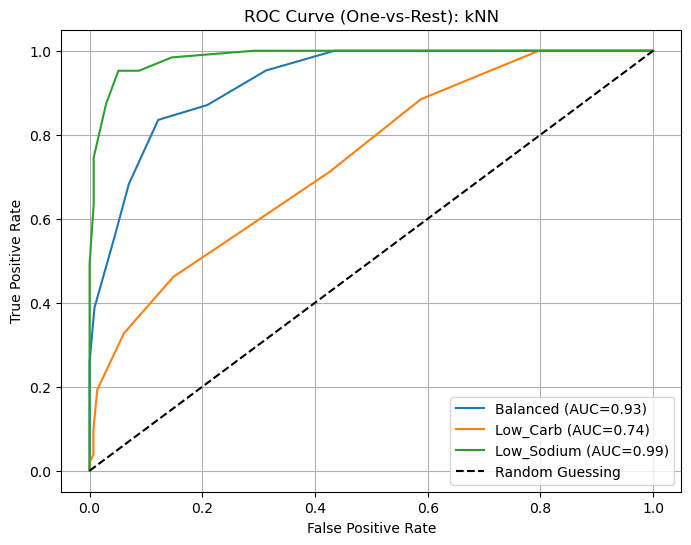

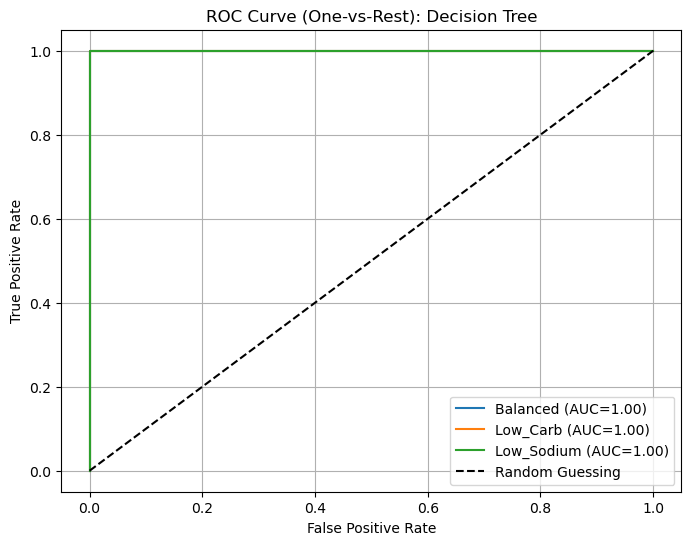

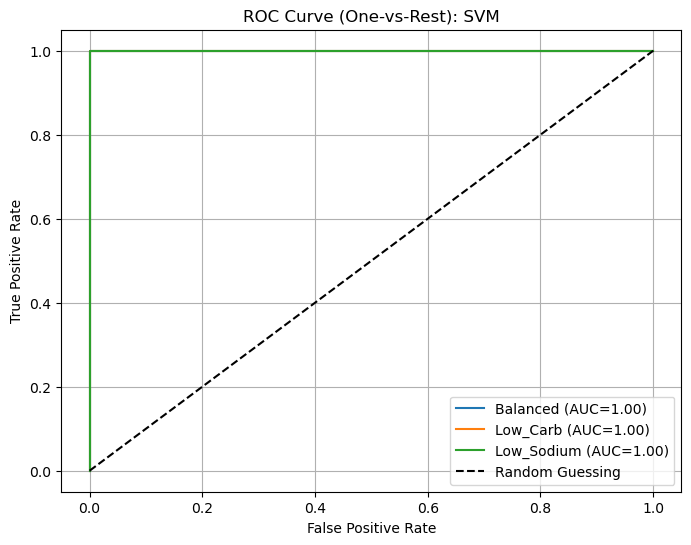

In [11]:
def plot_multiclass_roc(model, model_name, X_test, y_test):
    """
    Plots a multi-class ROC (Receiver Operating Characteristic)
    curve for a classification model using a one-vs-rest (OvR) approach.

    Inputs
    -------
    model: sklearn classifier
        A trained classification model that supports 'predict_proba()'.
    model_name : str
        Name of the model to display in the plot title.
    X_test : array-like
        Feature matrix for the test set.
    y_test : array-like
        True class labels for the test set.

    Output
    -------
    None
        Displays a ROC curve plot showing one ROC line per class.
    """

    """
    This function plots a multiclass ROC curve using a One-vs-Rest approach. 
    First, I extract the unique classes and binarize the true labels so ROC 
    can be computed separately for each class. I then get predicted probabilities 
    using predict_proba, because ROC depends on probability scores. For each class, 
    I compute the False Positive Rate and True Positive Rate at different thresholds, 
    calculate the AUC, and plot a ROC curve. I also add a diagonal baseline for random guessing. 
    Finally, I label the axes and show the plot. 
    This visualization helps me evaluate how well the model separates each diet category across all decision thresholds
    """
    # A ROC curve shows how well a classifier can distinguish 
    # between classes across all possible classification thresholds.
    
    # Identify all unique class labels in the test data
    classes = np.unique(y_test)

    # Convert true labels to one-hot encoded matrix for multi-class ROC
    y_test_bin = label_binarize(y_test, classes=classes)
    
    # Predict probabilities (SVM must be trained with probability=True)
    y_score = model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))

    # Compute and plot ROC curve for each class separately
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = auc(fpr, tpr)

        # Plot the ROC line for the current class
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc_score:.2f})")

    # Add baseline reference (random classifier)
    plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")

    # Add labels and formatting
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (One-vs-Rest): {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# Plot ROC for each model
plot_multiclass_roc(knn_cv, "kNN", X_test, y_test)
plot_multiclass_roc(tree_cv, "Decision Tree", X_test, y_test)
plot_multiclass_roc(svm_cv, "SVM", X_test, y_test)

# Results
**3. What are the top foods that can be recommended to help individuals meet their nutrient targets in each category of nutrients? (Low_Carb, Low_Sodium, and Balanced)**

I used the nutrient composition dataset to identify foods that best align with the nutrient needs of each diet category. Specifically, I ranked foods by their carbohydrate or sodium content (depending on the diet type) and removed any items that contained allergens based on the user’s reported dietary restrictions.
This allowed me to generate a dataframe of the top recommended foods for Low_Carb and Low_Sodium diets. For individuals in the Balanced category, no specific restrictions apply; they can generally continue eating a wide variety of foods while maintaining their normal habits.

Below the code output, I show sample results demonstrating the top 10 lowest-carbohydrate foods and top 10 lowest-sodium foods with and without filtering for allergies. Codes can be modified depending on different cases.

In [12]:
# Allergen keyword lists (approximation)
gluten_keywords = [
    # Core gluten grains
    "wheat", "barley", "rye", "triticale", "spelt", "farro",
    "semolina", "durum",
    
    # Flours
    "wheat flour", "all-purpose flour", "bread flour", "cake flour",
    "semolina flour", "rye flour", "graham flour",
    
    # Bakery & carbs
    "bread", "bagel", "biscuit", "bun", "roll", "croissant", "muffin",
    "cake", "brownie", "cookie", "cracker", "pretzel", "donut",
    "pastry", "scone", "waffle", "pancake",
    
    # Pasta & noodles
    "pasta", "noodle", "spaghetti", "ramen", "udon", "lasagna", "fettuccine",
    
    # Breaded foods
    "breadcrumbs", "breaded", "battered", "crouton",
    
    # Snack foods
    "cereal", "granola", "barley soup", "wheat cereal",
]

peanut_keywords = [
    "peanut",
    "peanut butter",
    "groundnut",
    "satay",                # usually peanut-based sauce
    "kung pao",             # often contains peanuts
    "pad thai",             # often contains crushed peanuts
    "peanut oil",
    "nut bar",
    "trail mix",            # may contain peanuts
    "peanut sauce",
]

allergen_keywords = {
    "gluten": gluten_keywords,
    "peanut": peanut_keywords,
}

In [13]:
def remove_allergic_foods(df, allergen, food_col="descrip"):
    """
    Takes in a nutrient dataframe that contains a column of food name, 
    a string of the food column name, and a string of a specific allergen.
    Expected allergen values include "Gluten", "Peanut", or "None".
    Removes foods whose names contain obvious allergen keywords.
    Returns a filtered dataframe without the specific allergen.
    """
    df_filtered = df.copy()
    
    # If allergen is None or "None", we don't filter anything
    if allergen in ["None", None]:
        return df_filtered
    
    # Get all keywords for the given allergen (Gluten or Peanut)
    keywords = allergen_keywords.get(allergen, [])

    for kw in keywords:
        # str.contains is a pandas string-matching function that checks whether 
        # a substring appears inside another string.
        # case=False: ignore capitalization
        # na=False: treat missing values as not containing the keyword
        contains_kw = df_filtered[food_col].str.contains(kw, case=False, na=False)
        df_filtered = df_filtered[~contains_kw]

    
    return df_filtered


# Testing
test_foods = pd.DataFrame({
    "descrip": [
        "Peanut Butter Sandwich",   # contains peanut
        "Whole Wheat Bread",        # contains gluten
        "Grilled Chicken",          # safe
        "Rice Noodles",             # contains noodle: gluten
        "APPLE",                    # upper-case safety check
        None                        # missing value
    ],
    # A DataFrame requires at least one additional column when testing filtering functions.
    "value": [1, 2, 3, 4, 5, 6]  # dummy column
})

# Peanut allergy removes peanut-containing foods
df_peanut = remove_allergic_foods(test_foods, "peanut")
assert "Peanut Butter Sandwich" not in df_peanut["descrip"].values
assert len(df_peanut) == 5  # only peanut-containing one removed

# Gluten allergy removes wheat/noodle foods
df_gluten = remove_allergic_foods(test_foods, "gluten")
assert "Whole Wheat Bread" not in df_gluten["descrip"].values
assert "Rice Noodles" not in df_gluten["descrip"].values
assert len(df_gluten) == 4  # two items removed

# No allergy returns original data
df_none = remove_allergic_foods(test_foods, "None")
assert len(df_none) == len(test_foods)

# Case-insensitivity works
assert "APPLE" in df_gluten["descrip"].values  # should not be removed

# Missing values (None) should not crash or be removed
assert None in df_none["descrip"].values

print("All tests passed for remove_allergic_foods()!")

All tests passed for remove_allergic_foods()!


In [14]:
def get_top_foods_lowest(nutrient_df, nutrient_col, allergen=None, top_n=10):
    """
    Takes in a nutrient composition dataframe, a string name of the nutrient_col, 
    a string of an allergen or by default None, and an integer of the top number,
    returns the top n lowest-nutrient foods from the nutrient dataset,
    excluding foods that contain a specific allergen.
    """
    df = nutrient_df.copy()

    df = remove_allergic_foods(df, allergen)

    # Drop missing nutrient values
    df = df.dropna(subset=[nutrient_col])
    
    # Sort by nutrient ascending (lowest first)
    df_sorted = df.sort_values(by=nutrient_col, ascending=True)
    
    return df_sorted.head(top_n)


# Testing
nutrient_test = pd.DataFrame({
    "descrip": [
        "Whole Wheat Bread",   # gluten
        "Peanut Butter",       # peanut
        "Apple",               # safe
        "Chicken Breast",      # safe
        "Rice",                # safe
    ],
    "Carb_g": [45, 20, 14, 0, 28],
    "Sodium_mg": [300, 120, 1, 70, 5]
})

# Basic lowest-carb foods
result = get_top_foods_lowest(nutrient_test, nutrient_col="Carb_g", top_n=3)
assert list(result["descrip"]) == ["Chicken Breast", "Apple", "Peanut Butter"]

# Gluten removed
result_gluten = get_top_foods_lowest(nutrient_test, nutrient_col="Carb_g", allergen="gluten", top_n=5)
assert "Whole Wheat Bread" not in result_gluten["descrip"].values

# Peanut removed
result_peanut = get_top_foods_lowest(nutrient_test, nutrient_col="Carb_g", allergen="peanut", top_n=5)
assert "Peanut Butter" not in result_peanut["descrip"].values

# Missing nutrient values are dropped
nutrient_missing = nutrient_test.copy()
nutrient_missing.loc[3, "Carb_g"] = None  # Chicken Breast missing carb value
result_missing = get_top_foods_lowest(nutrient_missing, nutrient_col="Carb_g", top_n=5)
assert "Chicken Breast" not in result_missing["descrip"].values

# top_n works
result_top2 = get_top_foods_lowest(nutrient_test, nutrient_col="Sodium_mg", top_n=2)
assert len(result_top2) == 2
assert list(result_top2["descrip"]) == ["Apple", "Rice"]

print("All tests passed for get_top_foods_lowest()!")

All tests passed for get_top_foods_lowest()!


In [15]:
# Sample: Top 10 foods recommended
top_low_carb_none = get_top_foods_lowest(
    nutrient,
    nutrient_col="Carb_g",

    top_n=10
)

top_low_carb_gluten = get_top_foods_lowest(
    nutrient,
    nutrient_col="Carb_g",
    allergen="Gluten",
    top_n=10
)

top_low_carb_peanut = get_top_foods_lowest(
    nutrient,
    nutrient_col="Carb_g",
    allergen="Peanut",
    top_n=10
)


top_low_sodium_none = get_top_foods_lowest(
    nutrient,
    nutrient_col="Sodium_mg",
    top_n=10
)

top_low_sodium_gluten = get_top_foods_lowest(
    nutrient,
    nutrient_col="Sodium_mg",
    allergen="Gluten",
    top_n=10
)

top_low_sodium_peanut = get_top_foods_lowest(
    nutrient,
    nutrient_col="Sodium_mg",
    allergen="Peanut",
    top_n=10
)

print("Top 10 Lowest-Carbohydrate Foods (No Allergies):")
display(top_low_carb_none)

print("Top 10 Lowest-Carbohydrate Foods (Gluten Removed):")
display(top_low_carb_gluten)

print("Top 10 Lowest-Carbohydrate Foods (Peanut Removed):")
display(top_low_carb_peanut)

print("\nTop 10 Lowest-Sodium Foods (No Allergies):")
display(top_low_sodium_none)

print("\nTop 10 Lowest-Sodium Foods (Gluten Removed):")
display(top_low_sodium_gluten)

print("\nTop 10 Lowest-Sodium Foods (Peanut Removed):")
display(top_low_sodium_peanut)

Top 10 Lowest-Carbohydrate Foods (No Allergies):


,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,VitC_mg,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg
4658,15181,salmon pink cnd wosalt sol wboneliq,139.0,19.78,1.535,6.05,0.0,0.0,0.0,213.0,...,0.0,0.023,0.186,6.536,0.300,15.0,4.40,17.0,0,0.0
4545,15064,pike walleye raw,93.0,19.14,0.249,1.22,0.0,0.0,0.0,110.0,...,0.0,0.270,0.160,2.300,0.120,15.0,2.00,21.0,0,0.0
4546,15065,pollock atlantic raw,92.0,19.44,0.135,0.98,0.0,0.0,0.0,60.0,...,0.0,0.047,0.185,3.270,0.287,3.0,3.19,14.0,0.23,1.0
4547,15066,fish pollock alaska raw (may have been previou...,56.0,12.19,0.124,0.41,0.0,0.0,0.0,15.0,...,0.0,0.030,0.080,0.653,0.069,3.0,1.63,3.0,0.49,0.2
4548,15067,fish pollock alaska ckd dry heat (maybe previo...,111.0,23.48,0.159,1.18,0.0,0.0,0.0,72.0,...,0.0,0.054,0.223,3.949,0.329,3.0,3.66,17.0,0.28,1.3
4549,15068,pompano florida raw,164.0,18.48,3.509,9.47,0.0,0.0,0.0,22.0,...,0.0,0.560,0.120,3.000,0.200,15.0,1.30,40.0,0.18,11.0
4550,15069,pompano florida ckd dry heat,211.0,23.69,4.499,12.14,0.0,0.0,0.0,43.0,...,0.0,0.680,0.150,3.800,0.230,17.0,1.20,36.0,0,0.0
4551,15070,rockfish pacific mxd sp raw,90.0,18.36,0.347,1.34,0.0,0.0,0.0,14.0,...,0.0,0.023,0.187,2.393,0.210,9.0,1.39,4.0,0.36,3.8
4552,15071,rockfish pacific mxd sp ckd dry heat,109.0,22.23,0.420,1.62,0.0,0.0,0.0,17.0,...,0.0,0.027,0.226,2.897,0.241,10.0,1.59,5.0,0.44,4.6
4554,15073,roughy orange raw,76.0,16.41,0.015,0.70,0.0,0.0,0.0,9.0,...,0.0,0.031,0.045,1.530,0.052,26.0,0.38,21.0,1.2,0.0


Top 10 Lowest-Carbohydrate Foods (Gluten Removed):


,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,VitC_mg,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg
4658,15181,salmon pink cnd wosalt sol wboneliq,139.0,19.78,1.535,6.05,0.0,0.0,0.0,213.0,...,0.0,0.023,0.186,6.536,0.300,15.0,4.40,17.0,0,0.0
4545,15064,pike walleye raw,93.0,19.14,0.249,1.22,0.0,0.0,0.0,110.0,...,0.0,0.270,0.160,2.300,0.120,15.0,2.00,21.0,0,0.0
4546,15065,pollock atlantic raw,92.0,19.44,0.135,0.98,0.0,0.0,0.0,60.0,...,0.0,0.047,0.185,3.270,0.287,3.0,3.19,14.0,0.23,1.0
4547,15066,fish pollock alaska raw (may have been previou...,56.0,12.19,0.124,0.41,0.0,0.0,0.0,15.0,...,0.0,0.030,0.080,0.653,0.069,3.0,1.63,3.0,0.49,0.2
4548,15067,fish pollock alaska ckd dry heat (maybe previo...,111.0,23.48,0.159,1.18,0.0,0.0,0.0,72.0,...,0.0,0.054,0.223,3.949,0.329,3.0,3.66,17.0,0.28,1.3
4549,15068,pompano florida raw,164.0,18.48,3.509,9.47,0.0,0.0,0.0,22.0,...,0.0,0.560,0.120,3.000,0.200,15.0,1.30,40.0,0.18,11.0
4550,15069,pompano florida ckd dry heat,211.0,23.69,4.499,12.14,0.0,0.0,0.0,43.0,...,0.0,0.680,0.150,3.800,0.230,17.0,1.20,36.0,0,0.0
4551,15070,rockfish pacific mxd sp raw,90.0,18.36,0.347,1.34,0.0,0.0,0.0,14.0,...,0.0,0.023,0.187,2.393,0.210,9.0,1.39,4.0,0.36,3.8
4552,15071,rockfish pacific mxd sp ckd dry heat,109.0,22.23,0.420,1.62,0.0,0.0,0.0,17.0,...,0.0,0.027,0.226,2.897,0.241,10.0,1.59,5.0,0.44,4.6
4554,15073,roughy orange raw,76.0,16.41,0.015,0.70,0.0,0.0,0.0,9.0,...,0.0,0.031,0.045,1.530,0.052,26.0,0.38,21.0,1.2,0.0


Top 10 Lowest-Carbohydrate Foods (Peanut Removed):


...

,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,VitC_mg,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg
662,4060,oil sunflower linoleic (less than 60),884.0,0.0,10.100,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.08,0.0
697,4542,fat chicken,900.0,0.0,29.800,99.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7,4.8
696,4541,oil cupu assu,884.0,0.0,53.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0
694,4536,oil sheanut,884.0,0.0,46.600,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
693,4534,oil babassu,884.0,0.0,81.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.1,0.0
692,4532,oil hazelnut,884.0,0.0,7.400,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.2,0.0
691,4531,oil soybn lecithin,763.0,0.0,15.005,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.18,0.0
690,4530,oil apricot kernel,884.0,0.0,6.300,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0
689,4529,oil almond,884.0,0.0,8.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.2,0.0
688,4528,oil walnut,884.0,0.0,9.100,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0



Top 10 Lowest-Sodium Foods (Gluten Removed):


,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,VitC_mg,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg
662,4060,oil sunflower linoleic (less than 60),884.0,0.0,10.100,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.08,0.0
697,4542,fat chicken,900.0,0.0,29.800,99.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7,4.8
696,4541,oil cupu assu,884.0,0.0,53.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0
694,4536,oil sheanut,884.0,0.0,46.600,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
693,4534,oil babassu,884.0,0.0,81.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.1,0.0
692,4532,oil hazelnut,884.0,0.0,7.400,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.2,0.0
691,4531,oil soybn lecithin,763.0,0.0,15.005,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.18,0.0
690,4530,oil apricot kernel,884.0,0.0,6.300,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0
689,4529,oil almond,884.0,0.0,8.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.2,0.0
688,4528,oil walnut,884.0,0.0,9.100,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0



Top 10 Lowest-Sodium Foods (Peanut Removed):


,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,VitC_mg,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg
662,4060,oil sunflower linoleic (less than 60),884.0,0.0,10.100,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.08,0.0
697,4542,fat chicken,900.0,0.0,29.800,99.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7,4.8
696,4541,oil cupu assu,884.0,0.0,53.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0
694,4536,oil sheanut,884.0,0.0,46.600,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
693,4534,oil babassu,884.0,0.0,81.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.1,0.0
692,4532,oil hazelnut,884.0,0.0,7.400,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.2,0.0
691,4531,oil soybn lecithin,763.0,0.0,15.005,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.18,0.0
690,4530,oil apricot kernel,884.0,0.0,6.300,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0
689,4529,oil almond,884.0,0.0,8.200,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.2,0.0
688,4528,oil walnut,884.0,0.0,9.100,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0


---
# Impact and Limitations
**Who might benefit from this analysis?**

Individuals who are trying to improve their health through diet—especially those with chronic conditions such as diabetes, hypertension, or obesity—may benefit from this analysis. The machine-learning models can predict an appropriate diet recommendation using personal demographic and lifestyle information, and the nutrient-based ranking system can offer examples of foods that fit the nutritional needs of each diet category. This type of analysis can help people better understand which dietary patterns align with their health risk factors, and provide an accessible starting point for making informed food choices.


**Who might be excluded or harmed?**

Despite its usefulness, this analysis may unintentionally exclude or misguide certain groups.
Individuals with severe or uncommon food allergies could be harmed if they rely on the food recommendations without professional oversight, because the nutrient dataset does not reliably identify allergenic ingredients. People whose diets are shaped by cultural, religious, or economic constraints may also feel excluded, since the model does not incorporate cultural cuisine patterns, food availability, or cost. Finally, if someone treats the predicted diet category as a medical diagnosis rather than a suggestion, the system could lead to confusion or inappropriate self-management of a health condition. For these reasons, the results should be viewed as informational rather than prescriptive.


**How did the data setting impact the results?**

The structure of the dataset strongly influenced the machine-learning outcomes. Several features—such as Disease_Type, Dietary_Restrictions, Glucose level, and Nutrient Imbalance Scores—were closely aligned with the target variable, which made the classes highly separable. This explains why the Decision Tree and SVM models achieved perfect accuracy and perfect AUC values: the dataset implicitly encodes rules that map directly to diet categories, making prediction almost deterministic.

Additionally, the nutrient-composition dataset includes extremely detailed food items (e.g., “olive oil,” “canola oil,” “sunflower oil”), which means the “top 10” rankings are often dominated by many detailed food items or isolated ingredients rather than balanced foods. This affects the interpretability and practicality of the food recommendations. Also, the main cause is because of my choice of dataset. I did not think too much about the highly similar food items. What I was concerned about before was just whether the dataset contains the needed features like carbohydrate and sodium.


## Limitations
1. Limited and unreliable allergen identification

The nutrient dataset does not include ingredient lists or reliable allergy labels. So what I did was just simple allergen filtering, based on simple keywords of the food that might contain the allergens (e.g., detecting “peanut” or “wheat”).
This approach only catches obvious cases, misses hidden or processed ingredients, may accidentally remove safe foods, and only handles Gluten, Peanut, and None, because those are the only options in the dataset.

Because of this, the allergen-filtering system should be treated as a basic prototype rather than a medically safe tool.


2. Narrow coverage of food types

When identifying “top foods,” many of the top entries belonged to a very small category of foods. For example, the lowest-sodium list was dominated entirely by oils, and the lowest-carb list was dominated entirely by fish.
While technically correct, these are not realistic dietary recommendations.
This limitation arises because the dataset is ingredient-level rather than dish-level, some categories (e.g., fruits, vegetables, grains) are underrepresented, and a simple numeric ranking does not reflect dietary balance

In order to solve this limitation, more work is required, such as grouping foods, excluding non-meal items, or building nutritional heuristics. What people can do based on my work currently is to increase the top number or even directly see the whole dataframe, which consumes people's time.


3. Strong feature–label relationships may inflate model performance

The perfect accuracy seen in the Decision Tree and SVM models suggests that some features encode the diet recommendation very directly.
While this is not wrong, it means the model may not generalize to real-world patient data, the true predictive power of the algorithm may be overstated, and the results reflect how clean and structured the dataset is, not how messy real health data usually is.

This is very important because a perfect model in this context does not necessarily imply clinical usefulness.


4. The model cannot handle missing data without additional preprocessing

Another limitation is that the prediction system requires every input feature to be present. Because the model was trained on a complete set of numeric and categorical variables, it cannot generate predictions if a patient’s data is missing key values (such as cholesterol or glucose levels). In practice, real patient data often contains gaps, and additional preprocessing, such as imputation or medical estimation, would be needed to fill in these missing values. 


**How others should use these conclusions?**

These results should be viewed as early exploratory findings rather than strict nutrition advice. While the models show that health and lifestyle features can predict diet recommendations very accurately, using them in real life would require much more detailed data, professional nutrition input, and better ways to handle allergies and food categories.
Overall, this analysis helps understand general patterns in the dataset, but it should not be used as a medical or personalized diet plan.

---
### Now I will do a sample with SVM that shows how people can use my project to predict a person's dietary recommendation. I will show the corresponding food recommended as well.

In [16]:
# Example new patient
new_patient = {
    "Age": 45,
    "Gender": "Female",
    "BMI": 28.4,
    "Disease_Type": "Hypertension",
    "Severity": "Moderate",
    "Physical_Activity_Level": "Sedentary",
    "Daily_Caloric_Intake": 2100,
    "Cholesterol_mg/dL": 205,
    "Blood_Pressure_mmHg": 145,
    "Glucose_mg/dL": 110,
    "Dietary_Restrictions": "Low_Sodium",
    "Weekly_Exercise_Hours": 1,
    "Dietary_Nutrient_Imbalance_Score": 6.3,
    "Adherence_to_Diet_Plan": 70,
    "Allergies": "Gluten"
}

# Convert to dataframe (required for preprocessing + model pipeline)
new_patient_df = pd.DataFrame([new_patient])

# Use SVM to predict diet recommendation
svm_predicted_diet = svm_cv.predict(new_patient_df)[0]
print("Predicted Diet Recommendation with SVM:", svm_predicted_diet)

# Probability prediction
probs = svm_cv.predict_proba(new_patient_df)
probs_df = pd.DataFrame(probs, columns=svm_cv.classes_)
print(probs_df)

# Use the decision tree to predict diet recommendation
tree_predicted_diet = tree_cv.predict(new_patient_df)[0]
print("Predicted Diet Recommendation with Decision Tree:", tree_predicted_diet)

# Probability prediction
probs = tree_cv.predict_proba(new_patient_df)
probs_df = pd.DataFrame(probs, columns=tree_cv.classes_)
print(probs_df)

Predicted Diet Recommendation with SVM: Low_Sodium
   Balanced  Low_Carb  Low_Sodium
0  0.002604  0.011062    0.986334
Predicted Diet Recommendation with Decision Tree: Low_Sodium
   Balanced  Low_Carb  Low_Sodium
0       0.0       0.0         1.0


In [17]:
# Top 50 foods recommended based on Low_Sodium and gluten allergen
top_low_sodium_peanut = get_top_foods_lowest(
    nutrient,
    nutrient_col="Sodium_mg",
    allergen="Gluten",
    top_n=50
)
top_low_sodium_peanut

,NDB_No,Descrip,Energy_kcal,Protein_g,Saturated_fats_g,Fat_g,Carb_g,Fiber_g,Sugar_g,Calcium_mg,...,VitC_mg,Thiamin_mg,Riboflavin_mg,Niacin_mg,VitB6_mg,Folate_mcg,VitB12_mcg,VitA_mcg,VitE_mg,VitD2_mcg
662,4060,oil sunflower linoleic (less than 60),884.0,0.00,10.100,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,41.08,0.0
697,4542,fat chicken,900.0,0.00,29.800,99.80,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,2.7,4.8
696,4541,oil cupu assu,884.0,0.00,53.200,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.6,0.0
694,4536,oil sheanut,884.0,0.00,46.600,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0,0.0
693,4534,oil babassu,884.0,0.00,81.200,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,19.1,0.0
692,4532,oil hazelnut,884.0,0.00,7.400,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,47.2,0.0
691,4531,oil soybn lecithin,763.0,0.00,15.005,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,8.18,0.0
690,4530,oil apricot kernel,884.0,0.00,6.300,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,4,0.0
689,4529,oil almond,884.0,0.00,8.200,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,39.2,0.0
688,4528,oil walnut,884.0,0.00,9.100,100.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.4,0.0


---
# Challenge Goals

My original challenge goals included running three statistical hypothesis tests (ANOVA, t-test, and Chi-square) and building three machine-learning models (kNN, Decision Tree, and SVM) with full hyperparameter tuning and evaluation. Although these goals were appropriate for the project, I ended up expanding them in practice. 

Statistical testing required more steps than I anticipated—such as checking assumptions, writing helper functions, validating groups, and interpreting results carefully—which took significantly more time. In addition, learning new concepts like imputers, pipelines, ColumnTransformers, and ROC analysis took longer than I originally estimated. 

As a result, I underestimated both the time required for testing and the effort needed to learn and apply new machine-learning techniques. However, the extra time allowed me to deepen my understanding and produce more comprehensive and reliable results than my original plan.

---
# Plan Evaluation

My proposed work plan turned out to be less accurate than I expected, mainly because I underestimated the time required for the challenge goals. I originally planned for each task, like statistical testing, model tuning, and food recommendations, to take roughly similar amounts of time. In reality, the statistical hypothesis testing and the machine-learning section both required significantly more effort. I spent additional time learning new tools (such as GridSearchCV, ColumnTransformer, ROC curves, and so on). These steps were more complex and time-consuming than I anticipated, which caused the overall project to take longer than my initial estimates.

---
# Testing

I used a combination of doctests, assertions, and visual checks to ensure that my results were reliable. Doctests were included in my statistical helper functions to verify their behavior on small handcrafted datasets, while assertions were used to confirm that key steps, such as Chi-square expected frequencies, allergen filtering, and nutrient ranking, produced valid and consistent outputs. In addition to programmatic tests, I used visualizations as an informal verification method, such as boxplots and ROC curves. These allowed me to visually inspect whether the statistical and ML results made sense. For example, verifying that the ROC curves reflected well-separated classes for models with perfect accuracy. Together, these checks help demonstrate that my analysis and code can be trusted.